## Import files from google drive



In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
DATA_PATH = '/content/gdrive/MyDrive/DSSI Data/'

Mounted at /content/gdrive


### Under Sampling Annotated (PA)

In [11]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler

# load PA data
df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/pa_transactor_annotated_clean.csv")

# clean the label column
df['transactor_type'] = df['transactor_type'].astype(str).str.strip().str.title()

# drop rows with missing information
df = df.dropna(subset=['transactor_type', 'full_name'])

# remove duplicates
df = df.drop_duplicates(subset=['id', 'full_name'])

# label for undersampling
df['label'] = df['transactor_type'].factorize()[0]

# use label for both X and y
X = df[['label']]
y = df['label']

# undersample to get equal class distribution
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# get the balanced dataframe by selecting corresponding rows from original df
df_balanced = df.loc[y_resampled.index].reset_index(drop=True)

# check class balance
print(df_balanced['transactor_type'].value_counts())


transactor_type
Committee    1952
Candidate    1952
Name: count, dtype: int64


##Train Test Split (70 train, 20 Test, 10 Validation)

In [2]:
from sklearn.model_selection import train_test_split

# split out 20% test data
X_temp, X_test, y_temp, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_resampled
)

# split remaining 80% into 70% train and 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)
# print train test split sizes
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 2732
Validation size: 391
Test size: 781


### Under Sampling Annotated (AZ)

In [1]:
import pandas as pd
from imblearn.under_sampling import RandomUnderSampler

# load AZ dataset
df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/az_transactors_clean.csv")

# clean the label column
df['transactor_type'] = df['transactor_type'].astype(str).str.strip().str.title()

# drop rows with missing information
df = df.dropna(subset=['transactor_type', 'full_name'])

# remove "party" and keep only relevant categories
df = df[df['transactor_type'].isin(['Individual', 'Company', 'Committee'])]

# merge company and committee into organization
df['transactor_type'] = df['transactor_type'].replace({
    'Company': 'Organization',
    'Committee': 'Organization'
})

# remove duplicates
df = df.drop_duplicates(subset=['id', 'full_name'])

# label for undersampling
df['label'] = df['transactor_type'].factorize()[0]

# use label for both X and y
X = df[['label']]
y = df['label']

# undersample to get equal number of individuals and organizations
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# select the balanced rows from original df
df_balanced = df.loc[y_resampled.index].reset_index(drop=True)

# print balanced classes
print(df_balanced['transactor_type'].value_counts())



transactor_type
Organization    68485
Individual      68485
Name: count, dtype: int64


##:Train Test Split (70 train, 20 Test, 10 Validation)

In [2]:
from sklearn.model_selection import train_test_split

# split out 20% test data
X_temp, X_test, y_temp, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_resampled
)

# split remaining 80% into 70% train and 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=42,
    stratify=y_temp
)
# print train test split sizes
print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 95879
Validation size: 13697
Test size: 27394


##Plot Before vs After Undersampling Results (PA/AZ)

PA counts before balancing:
group
Organization    8173
Individual      1952
Name: count, dtype: int64

AZ counts before balancing:
group
Individual      439707
Organization     68486
Name: count, dtype: int64

PA counts after balancing:
group
Individual      1952
Organization    1952
Name: count, dtype: int64

AZ counts after balancing:
group
Individual      68486
Organization    68486
Name: count, dtype: int64


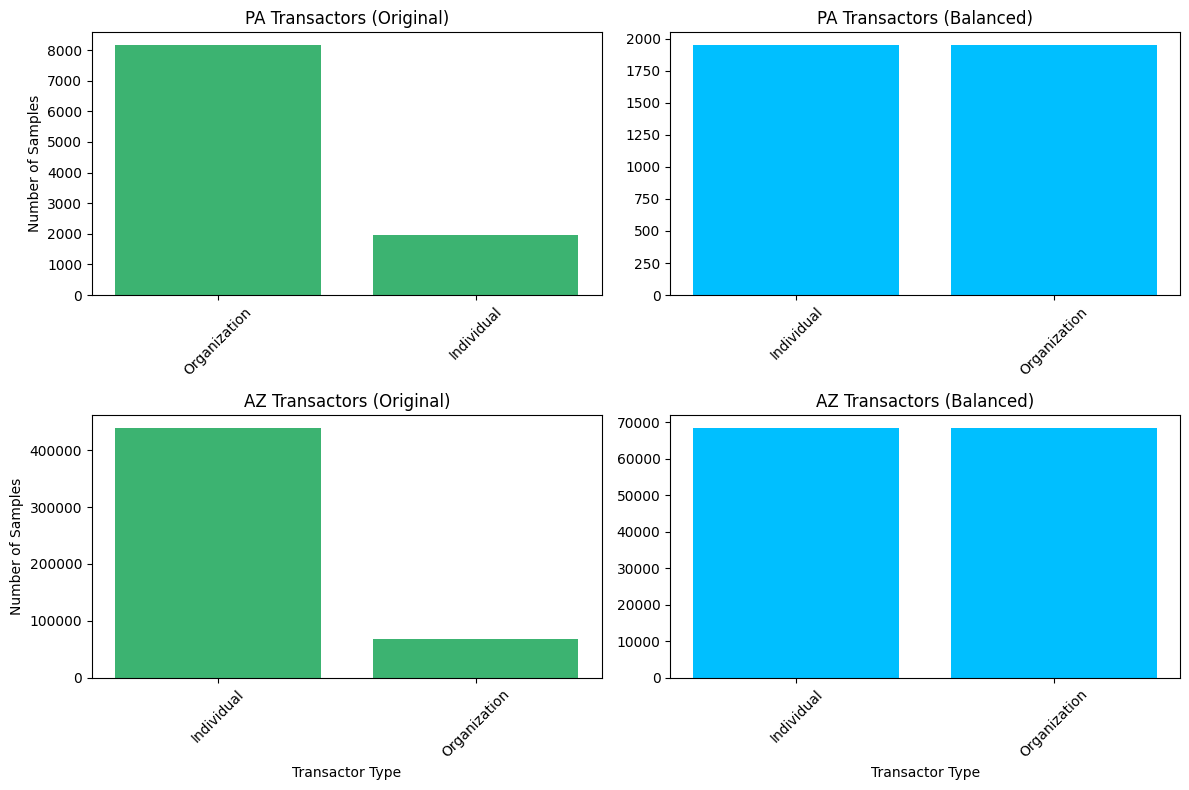

<Figure size 640x480 with 0 Axes>

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# load PA and AZ datasets
df_pa = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/pa_transactor_annotated_clean.csv")
df_az = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/az_transactors_clean.csv")

# clean the label column
df_pa['transactor_type'] = df_pa['transactor_type'].astype(str).str.strip().str.title()
df_az['transactor_type'] = df_az['transactor_type'].astype(str).str.strip().str.title()

# map function for grouping categories
def map_group(x):
    if x in ['Individual', 'Candidate']:
        return 'Individual'
    elif x in ['Committee', 'Company']:
        return 'Organization'
    # drop unnecessary categories
    else:
        return None

# apply mapping
df_pa['group'] = df_pa['transactor_type'].apply(map_group)
df_az['group'] = df_az['transactor_type'].apply(map_group)

# filter to only mapped groups
df_pa_filtered = df_pa.dropna(subset=['group'])
df_az_filtered = df_az.dropna(subset=['group'])

# print counts before balancing
print("PA counts before balancing:")
print(df_pa_filtered['group'].value_counts())
print("\nAZ counts before balancing:")
print(df_az_filtered['group'].value_counts())

# undersample to balance
min_count_pa = df_pa_filtered['group'].value_counts().min()
min_count_az = df_az_filtered['group'].value_counts().min()

df_pa_balanced = df_pa_filtered.groupby('group').sample(n=min_count_pa, random_state=42)
df_az_balanced = df_az_filtered.groupby('group').sample(n=min_count_az, random_state=42)

# print counts after balancing
print("\nPA counts after balancing:")
print(df_pa_balanced['group'].value_counts())
print("\nAZ counts after balancing:")
print(df_az_balanced['group'].value_counts())

# graph for comparison

# counts for plotting
pa_counts = df_pa_filtered['group'].value_counts()
pa_balanced_counts = df_pa_balanced['group'].value_counts()
az_counts = df_az_filtered['group'].value_counts()
az_balanced_counts = df_az_balanced['group'].value_counts()

# plot setup
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# PA Original
axes[0, 0].bar(pa_counts.index, pa_counts.values, color='mediumseagreen')
axes[0, 0].set_title('PA Transactors (Original)')
axes[0, 0].set_ylabel('Number of Samples')

# PA Balanced
axes[0, 1].bar(pa_balanced_counts.index, pa_balanced_counts.values, color='deepskyblue')
axes[0, 1].set_title('PA Transactors (Balanced)')

# AZ Original
axes[1, 0].bar(az_counts.index, az_counts.values, color='mediumseagreen')
axes[1, 0].set_title('AZ Transactors (Original)')
axes[1, 0].set_ylabel('Number of Samples')
axes[1, 0].set_xlabel('Transactor Type')

# AZ Balanced
axes[1, 1].bar(az_balanced_counts.index, az_balanced_counts.values, color='deepskyblue')
axes[1, 1].set_title('AZ Transactors (Balanced)')
axes[1, 1].set_xlabel('Transactor Type')

# labels
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.savefig("transactor_distribution.png", dpi=300, bbox_inches='tight')


# SVM Model


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

train_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/train.csv")
test_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/test.csv")

train_df
test_df

,Unnamed: 0,full_name,label
0,507706,quail creek crossing,0
1,225326,lyn t ward,1
2,141944,the governors,0
3,404422,briteverify,0
4,258567,u.s. american,0
...,...,...,...
38310,228830,thomas russo,1
38311,336128,colorado democratic party,0
38312,300745,andreini-brophy anna,1
38313,425221,jill blair,1


In [7]:
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])
X_train = vectorizer.transform(train_df['full_name'])
X_test = vectorizer.transform(test_df['full_name'])

y_train = train_df['label']
y_test = test_df['label']

X_test.shape, X_train.shape

((38315, 50669), (114945, 50669))

In [8]:
svc = svm.SVC(random_state=42)
svc.fit(X_train, y_train)
predicted_y = svc.predict(X_test)

accuracy = accuracy_score(y_test, predicted_y) * 100

recall = recall_score(y_test, predicted_y) * 100

precision = precision_score(y_test, predicted_y) * 100

f1= f1_score(y_test, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print()
print(classification_report(y_test, predicted_y))
print()
print(classification_report(y_test, predicted_y))

Accuracy: 90.59115229022576
Recall: 96.04384133611691
Precision: 86.6017224339969
F1 Score: 91.0787200871093
Precision: 86.6017224339969
Recall: 96.04384133611691

              precision    recall  f1-score   support

           0       0.96      0.85      0.90     19155
           1       0.87      0.96      0.91     19160

    accuracy                           0.91     38315
   macro avg       0.91      0.91      0.91     38315
weighted avg       0.91      0.91      0.91     38315


              precision    recall  f1-score   support

           0       0.96      0.85      0.90     19155
           1       0.87      0.96      0.91     19160

    accuracy                           0.91     38315
   macro avg       0.91      0.91      0.91     38315
weighted avg       0.91      0.91      0.91     38315



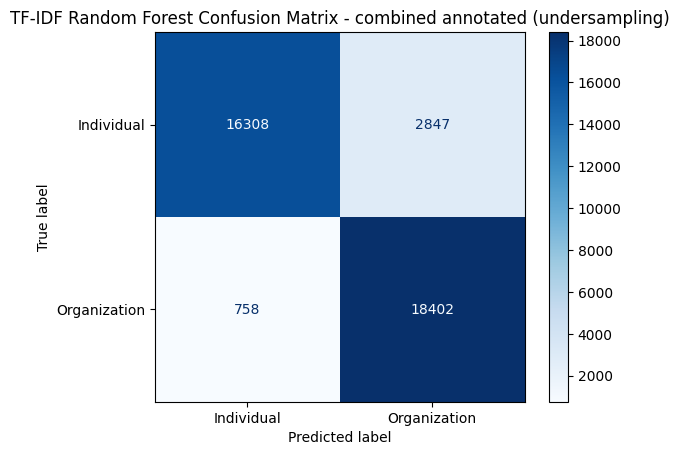

In [ ]:
cm = confusion_matrix(y_test, predicted_y, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)
plt.title("TF-IDF Random Forest Confusion Matrix - combined annotated (undersampling)")
#plt.savefig('TF-IDF Random Forest Confusion Matrix - combined annotated (undersampling).png', transparent=True, bbox_inches = 'tight')
plt.show()

Sigmoid kernel

In [ ]:
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split

# vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_df['full_name'])
X_test = vectorizer.transform(test_df['full_name'])

# sigmoid kernel, gamma = 1
model = svm.SVC(kernel='sigmoid', gamma=1.0, coef0=1)
model.fit(X_train, y_train)

# preds
predicted_y = model.predict(X_test)

# eval
accuracy = accuracy_score(y_test, predicted_y) * 100
f1 = f1_score(y_test, predicted_y, average='weighted') * 100
precision = precision_score(y_test, predicted_y, average='weighted') * 100
recall = recall_score(y_test, predicted_y, average='weighted') * 100

# results
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print()
print(classification_report(y_test, predicted_y))

Linear Kernel

In [ ]:
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split

# vectorization
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_df['full_name'])
X_test = vectorizer.transform(test_df['full_name'])

# linear kernel, c = 1
model = svm.SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)

# preds
predicted_y = model.predict(X_test)

# eval
accuracy = accuracy_score(y_test, predicted_y) * 100
f1 = f1_score(y_test, predicted_y, average='weighted') * 100
precision = precision_score(y_test, predicted_y, average='weighted') * 100
recall = recall_score(y_test, predicted_y, average='weighted') * 100

# results
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print()
print(classification_report(y_test, predicted_y))


Accuracy: 90.00913480360173
F1 Score: 89.95098908089354
Precision: 90.9552431059815
Recall: 90.00913480360173

              precision    recall  f1-score   support

           0       0.97      0.82      0.89     19155
           1       0.85      0.98      0.91     19160

    accuracy                           0.90     38315
   macro avg       0.91      0.90      0.90     38315
weighted avg       0.91      0.90      0.90     38315



SVM NEW DATA + OLD DATA


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
train_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/train.csv")
test_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/test.csv")

train_df
test_df

# load new data
general_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/mi_mn_annotated.csv")

# add new data to train set
extended_train_df = pd.concat([train_df, general_df], ignore_index=True)

#vectorizer
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])

X_train = vectorizer.transform(train_df['full_name'])
X_test = vectorizer.transform(test_df['full_name'])

y_train = train_df['label']
y_test = test_df['label']

# SVM
svc = svm.SVC(random_state=42)
svc.fit(X_train, y_train)

# preds
predicted_y = svc.predict(X_test)

# eval
accuracy = accuracy_score(y_test, predicted_y) * 100
recall = recall_score(y_test, predicted_y) * 100
precision = precision_score(y_test, predicted_y) * 100
f1= f1_score(y_test, predicted_y) * 100

# results
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print()
print(classification_report(y_test, predicted_y))
print()
print(classification_report(y_test, predicted_y))

Accuracy: 90.59115229022576
Recall: 96.04384133611691
Precision: 86.6017224339969
F1 Score: 91.0787200871093
Precision: 86.6017224339969
Recall: 96.04384133611691

              precision    recall  f1-score   support

           0       0.96      0.85      0.90     19155
           1       0.87      0.96      0.91     19160

    accuracy                           0.91     38315
   macro avg       0.91      0.91      0.91     38315
weighted avg       0.91      0.91      0.91     38315


              precision    recall  f1-score   support

           0       0.96      0.85      0.90     19155
           1       0.87      0.96      0.91     19160

    accuracy                           0.91     38315
   macro avg       0.91      0.91      0.91     38315
weighted avg       0.91      0.91      0.91     38315



SVM LINEAR KERNEL NEW DATA + OLD DATA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# original datasets
train_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/train.csv")
test_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/test.csv")

# new dataset
general_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/mi_mn_annotated.csv")

# combine training and new datasets
extended_train_df = pd.concat([train_df, general_df], ignore_index=True)

# drop mising values
extended_train_df = extended_train_df.dropna(subset=['full_name'])
test_df = test_df.dropna(subset=['full_name'])

# vectorization
vectorizer = TfidfVectorizer()
vectorizer.fit(extended_train_df['full_name'])

X_train = vectorizer.transform(extended_train_df['full_name'])
y_train = extended_train_df['label']

X_test = vectorizer.transform(test_df['full_name'])
y_test = test_df['label']

# linear kernel
svc = svm.SVC(kernel='linear', random_state=42)
svc.fit(X_train, y_train)

# preds
predicted_y = svc.predict(X_test)

# eval
accuracy = accuracy_score(y_test, predicted_y) * 100
recall = recall_score(y_test, predicted_y) * 100
precision = precision_score(y_test, predicted_y) * 100
f1 = f1_score(y_test, predicted_y) * 100

# results
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)
print()
print(classification_report(y_test, predicted_y))


Accuracy: 90.00913480360173
Recall: 97.60960334029227
Precision: 84.7317868793041
F1 Score: 90.71594877764842

              precision    recall  f1-score   support

           0       0.97      0.82      0.89     19155
           1       0.85      0.98      0.91     19160

    accuracy                           0.90     38315
   macro avg       0.91      0.90      0.90     38315
weighted avg       0.91      0.90      0.90     38315



In [ ]:
print(f1_score(y_test, predicted_y))

0.9071594877764843


Train Test Split MI/MN data



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
# load  MI/MN dataset
df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/mi_mn_annotated.csv")

Undersampling + new CSV files for PA, AZ, MI, MN

In [ ]:
import pandas as pd
from pathlib import Path

# define input files and whether they have label 1
csv_files = {
    "/content/gdrive/MyDrive/DSSI Data/pa_annotated_FINAL.csv": True,
    "/content/gdrive/MyDrive/DSSI Data/az_annotated_FINAL.csv": True,
    "/content/gdrive/MyDrive/DSSI Data/mn_annotated_data.csv": True,
    "/content/gdrive/MyDrive/DSSI Data/mi_annotated_data.csv": False  # only label 0 expected here
}

# target counts per label
target_0 = 2082  # organization
target_1 = 2776  # individuals

# output directory
output_dir = Path("/content/gdrive/MyDrive/DSSI Data/undersampled_csvs")
output_dir.mkdir(exist_ok=True)

for file_path, has_label_1 in csv_files.items():
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()

    df_0 = df[df['label'] == 0]
    df_1 = df[df['label'] == 1]

    if 'mi_annotated_data' in file_path:
        # only label 0 expected
        if len(df_0) < target_0:
            print(f"Warning: {file_path} has only {len(df_0)} label 0 rows, expected {target_0}")
            sampled_0 = df_0
        else:
            sampled_0 = df_0.sample(n=target_0, random_state=42)
        undersampled_df = sampled_0

    else:
        if len(df_0) < target_0:
            raise ValueError(f"{file_path} has only {len(df_0)} label 0 rows, needs {target_0}")
        sampled_0 = df_0.sample(n=target_0, random_state=42)

        if has_label_1:
            if len(df_1) < target_1:
                raise ValueError(f"{file_path} has only {len(df_1)} label 1 rows, needs {target_1}")
            sampled_1 = df_1.sample(n=target_1, random_state=42)
            undersampled_df = pd.concat([sampled_0, sampled_1])
        else:
            undersampled_df = sampled_0

    # randomize and save
    undersampled_df = undersampled_df.sample(frac=1, random_state=42).reset_index(drop=True)
    output_file = output_dir / f"undersampled_{Path(file_path).stem}.csv"
    undersampled_df.to_csv(output_file, index=False)
    print(f"Saved {output_file}")


Saved /content/gdrive/MyDrive/DSSI Data/undersampled_csvs/undersampled_pa_annotated_FINAL.csv
Saved /content/gdrive/MyDrive/DSSI Data/undersampled_csvs/undersampled_az_annotated_FINAL.csv
Saved /content/gdrive/MyDrive/DSSI Data/undersampled_csvs/undersampled_mn_annotated_data.csv
Saved /content/gdrive/MyDrive/DSSI Data/undersampled_csvs/undersampled_mi_annotated_data.csv


Confirm Undersampled totals for new csv files

In [ ]:
import pandas as pd

files = [
    "/content/gdrive/MyDrive/DSSI Data/undersampled_pa_annotated_FINAL.csv",
    "/content/gdrive/MyDrive/DSSI Data/undersampled_az_annotated_FINAL.csv",
    "/content/gdrive/MyDrive/DSSI Data/undersampled_mn_annotated_data.csv",
    "/content/gdrive/MyDrive/DSSI Data/undersampled_mi_annotated_data.csv"
]

for f in files:
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    print(f"{f} labels found: {df['label'].unique()}")
    print(df['label'].value_counts())
    print("-------")

/content/gdrive/MyDrive/DSSI Data/undersampled_pa_annotated_FINAL.csv labels found: [0 1]
label
1    2776
0    2082
Name: count, dtype: int64
-------
/content/gdrive/MyDrive/DSSI Data/undersampled_az_annotated_FINAL.csv labels found: [0 1]
label
1    2776
0    2082
Name: count, dtype: int64
-------
/content/gdrive/MyDrive/DSSI Data/undersampled_mn_annotated_data.csv labels found: [0 1]
label
1    2776
0    2082
Name: count, dtype: int64
-------
/content/gdrive/MyDrive/DSSI Data/undersampled_mi_annotated_data.csv labels found: [0]
label
0    2082
Name: count, dtype: int64
-------


SVM training on new csv files (train = PA test = MN)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
train_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/pa_annotated_FINAL.csv")
test_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/mn_annotated_data.csv")

train_df
test_df


vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])

X_train = vectorizer.transform(train_df['full_name'])
X_test = vectorizer.transform(test_df['full_name'])

y_train = train_df['label']
y_test = test_df['label']

svc = svm.SVC(random_state=42)
svc.fit(X_train, y_train)

predicted_y = svc.predict(X_test)

accuracy = accuracy_score(y_test, predicted_y) * 100

recall = recall_score(y_test, predicted_y) * 100

precision = precision_score(y_test, predicted_y) * 100

f1= f1_score(y_test, predicted_y) * 100

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)
print()
print(classification_report(y_test, predicted_y))
print()
print(classification_report(y_test, predicted_y))

Accuracy: 80.6438199986587
Recall: 80.15741450163684
Precision: 99.67606707317073
F1 Score: 88.85748920957741
Precision: 99.67606707317073
Recall: 80.15741450163684

              precision    recall  f1-score   support

           0       0.15      0.93      0.26      2770
           1       1.00      0.80      0.89     71785

    accuracy                           0.81     74555
   macro avg       0.58      0.87      0.58     74555
weighted avg       0.97      0.81      0.87     74555


              precision    recall  f1-score   support

           0       0.15      0.93      0.26      2770
           1       1.00      0.80      0.89     71785

    accuracy                           0.81     74555
   macro avg       0.58      0.87      0.58     74555
weighted avg       0.97      0.81      0.87     74555



SVM Linear Kernel train = PA AZ test = MI MN

In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# load data
train_df1 = pd.read_csv('/content/gdrive/MyDrive/DSSI Data/pa_annotated_FINAL.csv')
train_df2 = pd.read_csv('/content/gdrive/MyDrive/DSSI Data/az_annotated_FINAL.csv')
test_df1 = pd.read_csv('/content/gdrive/MyDrive/DSSI Data/mn_annotated_data.csv')
test_df2 = pd.read_csv('/content/gdrive/MyDrive/DSSI Data/mi_annotated_data.csv')

# combine training data
train_data = pd.concat([train_df1, train_df2], ignore_index=True)
train_data = train_data.dropna(subset=['full_name'])

# clean the label column
X_train = train_data.drop('full_name', axis=1)
y_train = train_data['full_name']

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# linear kernel
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)

# combine testing data
test_data = pd.concat([test_df1, test_df2], ignore_index=True)

# prepare test features
X_test = test_data.drop('label', axis=1)
y_test = test_data['label']

# apply scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

# eval
y_pred = svm_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

In [ ]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# load datasets

# train on PA AZ MI MN
paths_train = [
    '/content/gdrive/MyDrive/DSSI Data/pa_annotated_FINAL.csv',
    '/content/gdrive/MyDrive/DSSI Data/az_annotated_FINAL.csv',
    '/content/gdrive/MyDrive/DSSI Data/mn_annotated_data.csv',
    '/content/gdrive/MyDrive/DSSI Data/mi_annotated_data.csv',
]
#test on PA AZ MI MN
paths_test = [
    '/content/gdrive/MyDrive/DSSI Data/mn_annotated_data.csv',
    '/content/gdrive/MyDrive/DSSI Data/mi_annotated_data.csv',
    '/content/gdrive/MyDrive/DSSI Data/pa_annotated_FINAL.csv',
    '/content/gdrive/MyDrive/DSSI Data/az_annotated_FINAL.csv',
]

# read in the files
train_dfs = [pd.read_csv(p) for p in paths_train]
test_dfs = [pd.read_csv(p) for p in paths_test]

# combine train and test data
train_data = pd.concat(train_dfs, ignore_index=True).dropna(subset=['full_name'])
test_data = pd.concat(test_dfs, ignore_index=True).dropna(subset=['label'])

# feature columns
features = train_data.columns.intersection(test_data.columns).drop(['full_name', 'label'])

# numeric features only
X_train = train_data[features].select_dtypes(include=['number'])
X_test = test_data[features].select_dtypes(include=['number'])

y_train = train_data['full_name']
y_test = test_data['label']

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train LinearSVC (with max_iter for faster convergence)
svm = LinearSVC(max_iter=10000, random_state=42)
svm.fit(X_train_scaled, y_train)

# preds and evaluate
y_pred = svm.predict(X_test_scaled)
print(classification_report(y_test, y_pred))


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from imblearn.under_sampling import RandomUnderSampler
from sklearn import svm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# load data
train_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/test-all-states.csv")
test_df = pd.read_csv("/content/gdrive/MyDrive/DSSI Data/train-undersampled-all-states.csv")

# drop empty rows
train_df['full_name'] = train_df['full_name'].fillna('')  # or use train_df.dropna(subset=['full_name'], inplace=True)
test_df['full_name'] = test_df['full_name'].fillna('')

# vectorization
vectorizer = TfidfVectorizer()
vectorizer.fit(train_df['full_name'])


X_train = vectorizer.transform(train_df['full_name'])
X_test = vectorizer.transform(test_df['full_name'])

y_train = train_df['label']
y_test = test_df['label']

# svc
svc = svm.SVC(random_state=42)
svc.fit(X_train, y_train)

# preds
predicted_y = svc.predict(X_test)

# evals
accuracy = accuracy_score(y_test, predicted_y) * 100
recall = recall_score(y_test, predicted_y) * 100
precision = precision_score(y_test, predicted_y) * 100
f1 = f1_score(y_test, predicted_y) * 100

# results
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("F1 Score:", f1)
print()
print(classification_report(y_test, predicted_y))
